Import thư viện

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string #xử lý chuỗi liên quan tới bảng chữ cái, ký tự đặc biệt
import re #xử lý chuỗi bằng Regular Expression để làm sạch và trích xuất dữ liệu

from sklearn.linear_model import LogisticRegression             # mô hình phân loại logistic
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split            # chia dữ liệu train/test
from sklearn.feature_extraction.text import TfidfVectorizer     # biến text thành vector số (TF-IDF)
from sklearn.metrics import (
    accuracy_score,         # độ chính xác %
    classification_report,  # báo cáo precision, recall, f1-score
    confusion_matrix,       # Ma rận nhầm lẫn
    ConfusionMatrixDisplay  # vẽ trực quan confusion matrix
)

import joblib # tải model


Load data

In [ ]:
df = pd.read_csv('email.csv')

df = df.drop_duplicates() # xoá các dòng bị trùng nhau

print(f"Kích thước bộ dữ liệu là: {df.shape}")

# xem 5 dòng đầu
print("5 dòng đầu của dữ liệu: ")
display(df.head())

print("Kiểm tra phân bố nhãn: ")
print(df["Category"].value_counts())

Kích thước bộ dữ liệu là: (5157, 2)
5 dòng đầu của dữ liệu: 


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Kiểm tra phân bố nhãn: 
Category
ham     4516
spam     641
Name: count, dtype: int64


Tiền xử lý dữ liệu:

- Làm sạch và chuẩn hoá dữ liệu

In [43]:
# Tiền xử lý văn bản

def clean_text(text):
    text = text.lower()                                 # đổi "Free Money" thành "free money"
    text = re.sub(f"[{string.punctuation}]", "", text)  # xoá dấu câu: "Hello^^* Free?? Money." thành "Hello Free Money"
    text = re.sub(r"\d+", "", text)                     # xoá số: "win 1000 dollars now" thành "win dollars now"
    return text

df['Message'] = df['Message'].apply(clean_text)

- Mã hoá nhãn

In [48]:
df = df[df["Category"].isin(['ham', 'spam'])] # chỉ lấy các mẫu spam và ham

x = df["Message"]
y = df["Category"]

print("Kiểm tra phân bố nhãn: ")
print(y.value_counts())

print("\nKiểm tra phân bố nhãn theo tỷ lệ: ")
print(y.value_counts()/len(y))

y = y.map({
    'ham': 0,
    'spam': 1
}) # chuyển đổi nhãn thành số

Kiểm tra phân bố nhãn: 
Category
ham     4516
spam     641
Name: count, dtype: int64

Kiểm tra phân bố nhãn theo tỷ lệ: 
Category
ham     0.875703
spam    0.124297
Name: count, dtype: float64


Xử lý dữ liệu:

- Chia tập train/test

In [51]:
# Chia tập dữ liệu
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print("Đã chia train/test với tỉ lệ 80/20")

Đã chia train/test với tỉ lệ 80/20


- TF-IDF Vectorizer

In [52]:
# Chuyển đổi văn bản thành vector số
vectorizer = TfidfVectorizer()

# huấn luyện vectorizer với dữ liệu huấn luyện
vectorizer.fit(x_train)

# chuyển đổi dữ liệu huấn luyện thành vector số
x_train_tfidf = vectorizer.transform(x_train)

x_test_tfidf = vectorizer.transform(x_test)


Huấn luyện mô hình:

In [53]:
# sử dụng mô hình logistic regression
model = LogisticRegression(
    class_weight = "balanced"
)

model.fit(x_train_tfidf, y_train)

print("Đã huấn luyện mô hình")

Đã huấn luyện mô hình


Đánh giá mô hình:

Logistic Regression (train 80% / test 20%)
Accuracy:  0.9641472868217055

Confusion Matrix: 


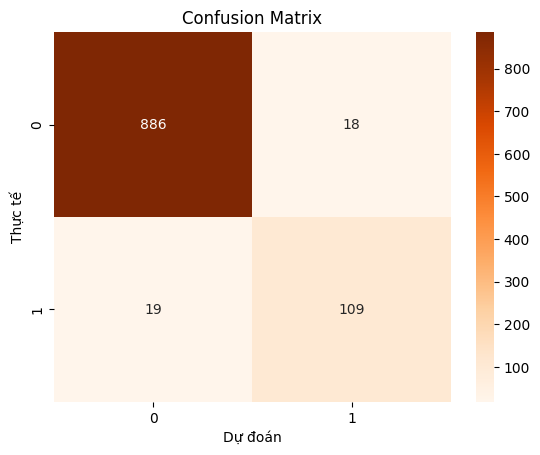


Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       904
           1       0.86      0.85      0.85       128

    accuracy                           0.96      1032
   macro avg       0.92      0.92      0.92      1032
weighted avg       0.96      0.96      0.96      1032



In [63]:
# Dự đoán nhãn trên tập test
y_pred = model.predict(x_test_tfidf)

# tính độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression (train 80% / test 20%)")
print("Accuracy: ", acc)

# vẽ ma trận nhầm lẫn
print("\nConfusion Matrix: ")
cm = confusion_matrix(y_test, y_pred)
plt.Figure(figsize=(4,4))
sns.heatmap(
    cm,             
    annot = True,   # in giá trị trong mỗi ô
    fmt = "d",      # định dãng số nguyên
    cmap = "Oranges"  # màu cam
)
plt.title("Confusion Matrix")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.show()

# báo cáo chi tiết các chỉ số: percision, recall, f1-score
print("\nClassification Report: ")
print(classification_report(y_test, y_pred))